# Démo YFinance

Ce notebook est destiné à illustrer le passage d'une exploration de données vers une application comme Streamlit.

Dans ce notebook, nous allons observer sommairement le cours d'une action.

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt

import plotly.graph_objects as go

Après avoir importé les ressources nécessaires, nous chargeons les données : actions Air Liquide sur une période d'un mois pour 1 jourd d'intervalle. Le paramètre `multi_level_index` permet de supprimer l'en-tête à plusieurs niveaux qui ne passera pas pour les graphs.

Ensuite, nous affichons simplement les données.

In [2]:
data = yf.download(tickers="AI.PA", period='1mo', interval='1d', multi_level_index=False)
data = data[data["High"] != data["Low"]]

[*********************100%***********************]  1 of 1 completed


In [3]:
data

,Close,High,Low,Open,Volume
Date,,,,,
2026-04-29,176.808472,178.002860,176.260216,177.611249,591417
2026-04-30,179.236404,179.236404,176.201480,176.221064,997447
2026-05-04,173.910599,178.648983,173.029499,178.511923,929713
2026-05-05,175.672821,176.181908,173.538580,174.341372,680566
2026-05-06,176.495178,178.257392,176.123151,176.221058,1253995
2026-05-07,172.990341,176.808473,172.089658,176.808473,1109221
2026-05-08,171.443497,172.539993,171.326021,171.815524,910679
2026-05-11,172.305038,172.520421,170.640731,171.326033,601438
2026-05-12,172.128815,173.225296,171.541405,171.933002,612937


Un affichage de courbe avec Matplotlib n'est pas utile : nous observons les variations de cours mais pas les tendances.

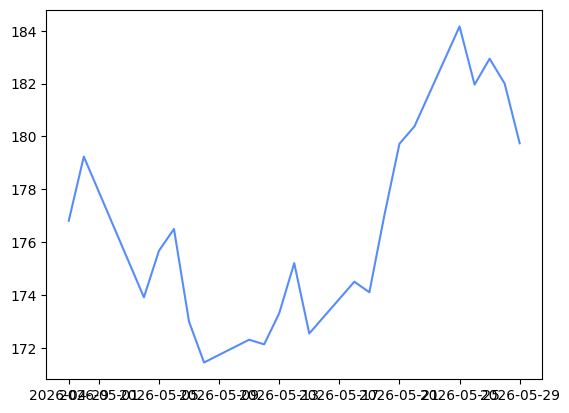

In [4]:
plt.plot(data.index, data.Close)
plt.show()

Plotly permet une représentation en *candlestick* où nous avons pour chaque interval la valeur plus haute, la plus basse, les cours d'ouverture et de fermeture et la tendance (hausse en vert, baisse en rouge).

In [5]:
fig = go.Figure(data=[go.Candlestick(x=data.index,
                                    open=data["Open"],
                                    high=data["High"],
                                    low=data["Low"],
                                    close=data['Close']
                                    )]
                )
fig.show()